# Notebook 1: Dane i przetwarzanie wstępne

## Analiza sentymentu recenzji aplikacji Spotify

**Opis:** Porównujemy podejście klasyczne (TF-IDF + Logistic Regression/SVM/Naive Bayes) z podejściem opartym na Transformerach (DistilBERT).

**Źródło danych:** Zbiór `mfaaris/spotify-app-reviews-2022` z Kaggle – publicznie dostępny zbiór recenzji aplikacji Spotify z ocenami 1–5.

W tym notebooku:
1. Pobieramy i ładujemy dane (via kagglehub)
2. Przeprowadzamy eksploracyjną analizę danych (EDA)
3. Wykonujemy przetwarzanie wstępne tekstu
4. Dzielimy dane na zbiory treningowy, walidacyjny i testowy

## 1. Instalacja i import bibliotek

In [1]:
!pip install -q kagglehub[pandas-datasets] pandas numpy matplotlib seaborn wordcloud spacy scikit-learn -q
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 99.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import spacy
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split

# Ustawienia wyświetlania
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 200)

## 2. Pobranie i załadowanie danych

Korzystamy ze zbioru `mfaaris/spotify-app-reviews-2022` dostępnego na Kaggle via `kagglehub`.
Zbiór zawiera angielskie recenzje aplikacji Spotify z ocenami od 1 do 5.

In [12]:
print("Pobieranie datasetu Spotify z Kaggle...")
df_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "mfaaris/spotify-app-reviews-2022",
    "reviews.csv"
)

# Usunięcie wierszy z brakującymi wartościami w kluczowych kolumnach
df_raw = df_raw.dropna(subset=['Review', 'Rating'])

# Ujednolicenie nazw kolumn do standardu używanego w dalszym kodzie
df_raw = df_raw.rename(columns={'Review': 'text', 'Rating': 'rating'})

print(f"Liczba rekordów: {len(df_raw)}")
print(f"Kolumny: {list(df_raw.columns)}")
df_raw.head()

Pobieranie datasetu Spotify z Kaggle...
Using Colab cache for faster access to the 'spotify-app-reviews-2022' dataset.
Liczba rekordów: 61594
Kolumny: ['Time_submitted', 'text', 'rating', 'Total_thumbsup', 'Reply']


,Time_submitted,text,rating,Total_thumbsup,Reply
0,2022-07-09 15:00:00,"Great music service, the audio is high quality and the app is easy to use. Also very quick and friendly support.",5,2,NaN
1,2022-07-09 14:21:22,Please ignore previous negative rating. This app is super great. I give it five stars+,5,1,NaN
2,2022-07-09 13:27:32,"This pop-up ""Get the best Spotify experience on Android 12"" is too annoying. Please let's get rid of this.",4,0,NaN
3,2022-07-09 13:26:45,Really buggy and terrible to use as of recently,1,1,NaN
4,2022-07-09 13:20:49,Dear Spotify why do I get songs that I didn't put on my playlist??? And why do we have shuffle play?,1,1,NaN


In [13]:
# Podgląd kolumn i typów
print("Podgląd kolumn i typów:")
print(df_raw.dtypes)
print("\nPrzykładowe wartości:")
df_raw.head(3)

Podgląd kolumn i typów:
Time_submitted    object
text              object
rating             int64
Total_thumbsup     int64
Reply             object
dtype: object

Przykładowe wartości:


,Time_submitted,text,rating,Total_thumbsup,Reply
0,2022-07-09 15:00:00,"Great music service, the audio is high quality and the app is easy to use. Also very quick and friendly support.",5,2,NaN
1,2022-07-09 14:21:22,Please ignore previous negative rating. This app is super great. I give it five stars+,5,1,NaN
2,2022-07-09 13:27:32,"This pop-up ""Get the best Spotify experience on Android 12"" is too annoying. Please let's get rid of this.",4,0,NaN


In [14]:
# Mapowanie ocen na sentyment (binarny)
# 1-2 -> negatywny (0), 4-5 -> pozytywny (1), 3 -> neutralny (pomijamy)
df_binary = df_raw.copy()

TEXT_COL = "text"
RATING_COL = "rating"

# Filtrowanie: usunięcie neutralnych recenzji (3 gwiazdki)
df_binary = df_binary[df_binary[RATING_COL] != 3].copy()

# Przypisanie etykiety sentymentu: 1-2 -> 0 (negatywny), 4-5 -> 1 (pozytywny)
df_binary["sentiment"] = df_binary[RATING_COL].apply(lambda x: 1 if x >= 4 else 0)

print(f"Liczba rekordów po odfiltrowaniu neutralnych: {len(df_binary)}")
print(f"\nRozkład sentymentu:")
print(df_binary["sentiment"].value_counts())
print(f"\nProporcje:")
print(df_binary["sentiment"].value_counts(normalize=True).round(3))

Liczba rekordów po odfiltrowaniu neutralnych: 54708

Rozkład sentymentu:
sentiment
1    29937
0    24771
Name: count, dtype: int64

Proporcje:
sentiment
1    0.547
0    0.453
Name: proportion, dtype: float64


## 3. Eksploracyjna analiza danych (EDA)

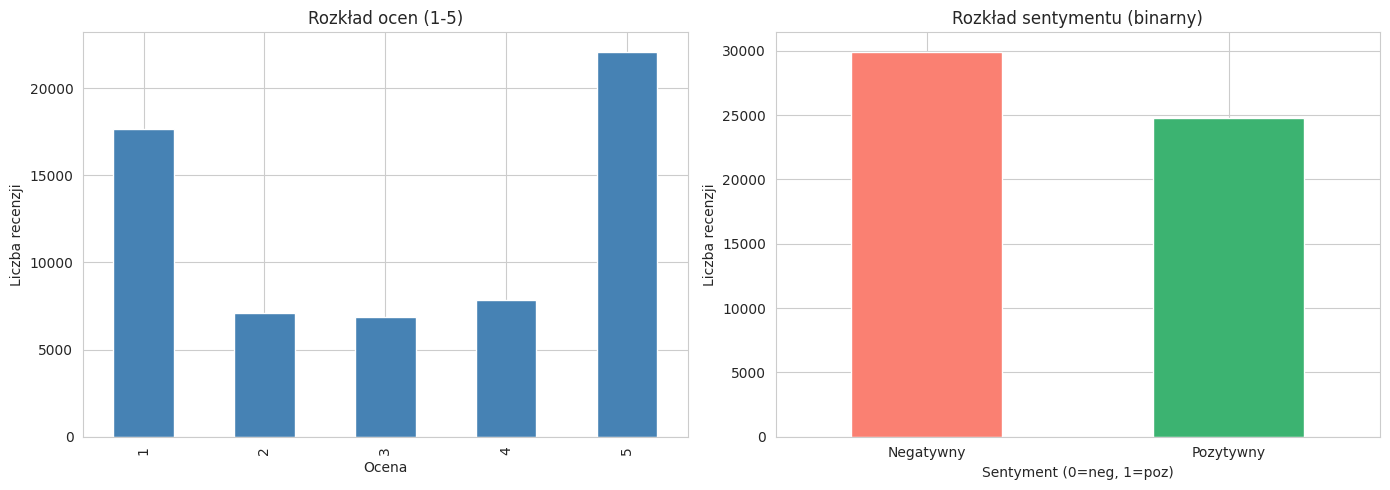

In [15]:
# Rozkład ocen w oryginalnym zbiorze
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rozkład oryginalnych ocen (surowe dane przed filtrowaniem)
df_raw[RATING_COL].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Rozkład ocen (1-5)")
axes[0].set_xlabel("Ocena")
axes[0].set_ylabel("Liczba recenzji")

# Rozkład sentymentu binarnego
df_binary["sentiment"].value_counts().plot(
    kind="bar", ax=axes[1], color=["salmon", "mediumseagreen"]
)
axes[1].set_title("Rozkład sentymentu (binarny)")
axes[1].set_xlabel("Sentyment (0=neg, 1=poz)")
axes[1].set_ylabel("Liczba recenzji")
axes[1].set_xticklabels(["Negatywny", "Pozytywny"], rotation=0)

plt.tight_layout()
plt.show()

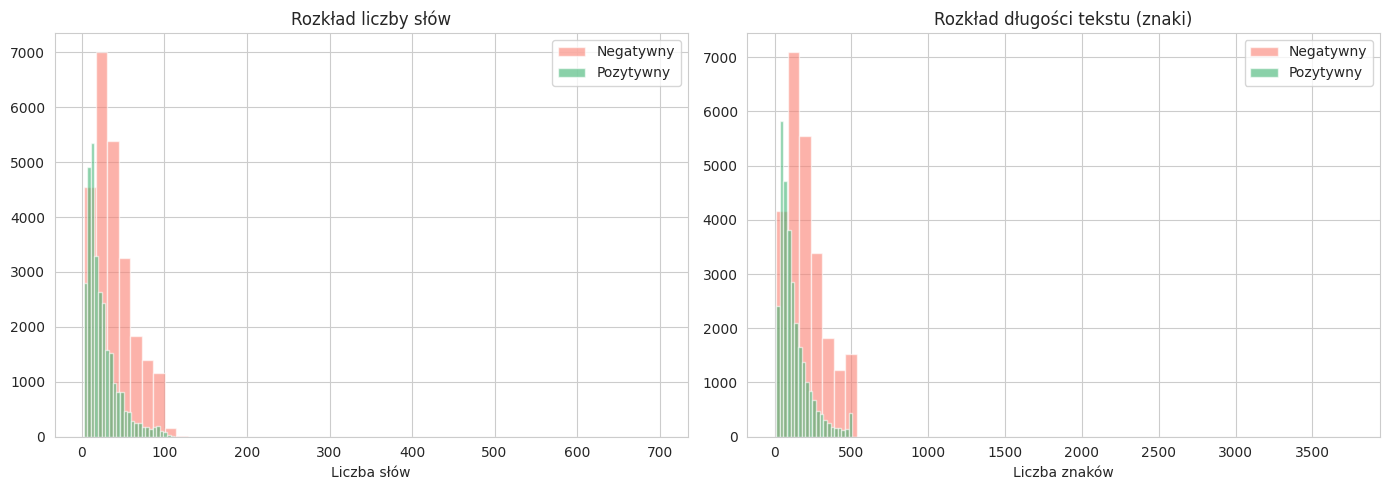

Statystyki długości recenzji (słowa):
             count       mean        std  min   25%   50%   75%    max
sentiment                                                             
0          24771.0  37.753987  23.902855  3.0  20.0  32.0  50.0  699.0
1          29937.0  23.808331  19.184321  2.0  10.0  18.0  31.0  222.0


In [16]:
# Długość recenzji
df_binary["text_length"] = df_binary[TEXT_COL].astype(str).apply(len)
df_binary["word_count"] = df_binary[TEXT_COL].astype(str).apply(
    lambda x: len(x.split())
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sent, color, label in [(0, "salmon", "Negatywny"), (1, "mediumseagreen", "Pozytywny")]:
    subset = df_binary[df_binary["sentiment"] == sent]
    axes[0].hist(subset["word_count"], bins=50, alpha=0.6, label=label, color=color)
    axes[1].hist(subset["text_length"], bins=50, alpha=0.6, label=label, color=color)

axes[0].set_title("Rozkład liczby słów")
axes[0].set_xlabel("Liczba słów")
axes[0].legend()

axes[1].set_title("Rozkład długości tekstu (znaki)")
axes[1].set_xlabel("Liczba znaków")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Statystyki długości recenzji (słowa):")
print(df_binary.groupby("sentiment")["word_count"].describe())

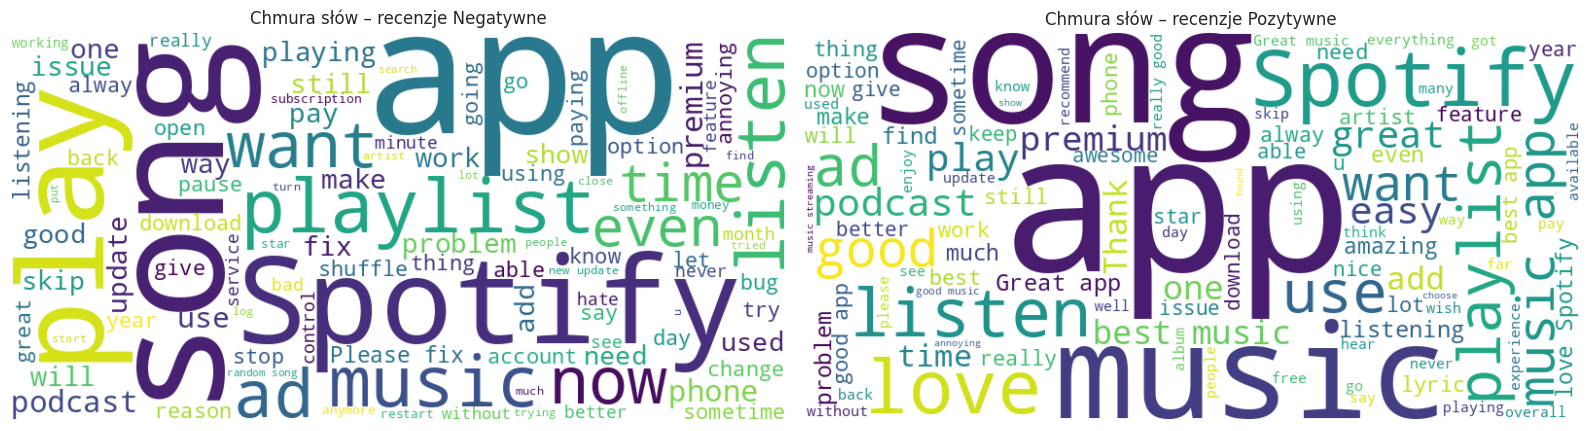

In [17]:
# Najczęstsze słowa dla każdego sentymentu
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (sent, title) in enumerate([(0, "Negatywne"), (1, "Pozytywne")]):
    texts = " ".join(df_binary[df_binary["sentiment"] == sent][TEXT_COL].astype(str))
    wc = WordCloud(
        width=800, height=400, background_color="white", max_words=100
    ).generate(texts)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"Chmura słów – recenzje {title}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 4. Przetwarzanie wstępne tekstu

In [18]:
# Ładowanie modelu spaCy dla języka angielskiego
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])


def preprocess_text(text):
    """Przetwarzanie wstępne tekstu: czyszczenie, lematyzacja, usunięcie stopwords."""
    if not isinstance(text, str):
        return ""

    # Zamiana na małe litery
    text = text.lower()

    # Usunięcie URL-i
    text = re.sub(r"http\S+|www\S+", "", text)

    # Usunięcie tagów HTML
    text = re.sub(r"<.*?>", "", text)

    # Usunięcie znaków specjalnych (zostawiamy litery, cyfry i spacje)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)

    # Lematyzacja i usunięcie stopwords za pomocą spaCy
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and len(token.text) > 1
    ]

    return " ".join(tokens)


# Przykład działania
sample_text = df_binary[TEXT_COL].iloc[0]
print(f"Oryginał: {sample_text[:200]}")
print(f"\nPo przetworzeniu: {preprocess_text(sample_text)[:200]}")

Oryginał: Great music service, the audio is high quality and the app is easy to use. Also very quick and friendly support.

Po przetworzeniu: great music service audio high quality app easy use quick friendly support


In [22]:
# Przetwarzanie wstępne dla podejścia klasycznego
# (Transformer będzie korzystał z surowego tekstu)
#limit 10000 aby nie trwalo dlugo poniewaz caly dataset ma ok 90000 rekordow
limit = 10000
df_binary = df_binary.head(limit).copy()
raw_data = df_binary[TEXT_COL].astype(str).tolist()

print(f"Rozpoczęto przetwarzanie {len(raw_data)} rekordów...")

# Przetwarzanie z licznikiem co 2000
processed_data = []
for i, text in enumerate(raw_data):
    processed_data.append(preprocess_text(text))

    # Warunek wyświetlający postęp co 3000 rekordów
    if (i + 1) % 2000 == 0:
        print(f"Przetworzono: {i + 1} / {len(raw_data)}")

df_binary["text_clean"] = processed_data

# Usunięcie pustych rekordów
df_binary = df_binary[df_binary["text_clean"].str.len() > 0].reset_index(drop=True)

Rozpoczęto przetwarzanie 10000 rekordów...
Przetworzono: 2000 / 10000
Przetworzono: 4000 / 10000
Przetworzono: 6000 / 10000
Przetworzono: 8000 / 10000
Przetworzono: 10000 / 10000


## 5. Podział na zbiory treningowy, walidacyjny i testowy

In [20]:
# Ograniczenie do rozsądnej liczby przykładów (Google Colab ma limity pamięci)
MAX_SAMPLES = 5000

if len(df_binary) > MAX_SAMPLES:
    df_sample = df_binary.sample(n=MAX_SAMPLES, random_state=42).reset_index(drop=True)
    print(f"Losowo wybrano {MAX_SAMPLES} próbek z {len(df_binary)}")
else:
    df_sample = df_binary.copy()
    print(f"Używamy pełnego zbioru: {len(df_sample)} próbek")

# Podział: 70% trening, 15% walidacja, 15% test
train_df, temp_df = train_test_split(
    df_sample, test_size=0.3, random_state=42, stratify=df_sample["sentiment"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df["sentiment"]
)

print(f"\nRozmiary zbiorów:")
print(f"  Treningowy: {len(train_df)}")
print(f"  Walidacyjny: {len(val_df)}")
print(f"  Testowy: {len(test_df)}")

print(f"\nRozkład sentymentu w zbiorze treningowym:")
print(train_df["sentiment"].value_counts(normalize=True))

Losowo wybrano 5000 próbek z 15000

Rozmiary zbiorów:
  Treningowy: 3500
  Walidacyjny: 750
  Testowy: 750

Rozkład sentymentu w zbiorze treningowym:
sentiment
1    0.617429
0    0.382571
Name: proportion, dtype: float64


In [21]:
# Zapis przetworzonych danych do plików CSV
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Dane zapisane do plików: train.csv, val.csv, test.csv")
print("\nKolumny w pliku:")
print(f"  '{TEXT_COL}' - oryginalny tekst (dla Transformerów)")
print(f"  'text_clean' - przetworzony tekst (dla podejścia klasycznego)")
print(f"  'sentiment' - etykieta (0=negatywny, 1=pozytywny)")

Dane zapisane do plików: train.csv, val.csv, test.csv

Kolumny w pliku:
  'text' - oryginalny tekst (dla Transformerów)
  'text_clean' - przetworzony tekst (dla podejścia klasycznego)
  'sentiment' - etykieta (0=negatywny, 1=pozytywny)


## Podsumowanie

W tym notebooku:
- Pobraliśmy zbiór recenzji aplikacji Spotify z Kaggle (via `kagglehub`)
- Zamieniliśmy oceny na sentyment binarny (pozytywny/negatywny), pomijając neutralne (3⭐)
- Przeprowadziliśmy EDA: rozkłady ocen, długości recenzji, chmury słów
- Wykonaliśmy przetwarzanie wstępne: czyszczenie, lematyzacja (spaCy `en_core_web_sm`), usunięcie stopwords
- Podzieliliśmy dane na zbiory: train (70%), val (15%), test (15%)

Dane są gotowe do użycia w kolejnych notebookach.